# IAT 461 / 882 — Assignment 2: Modeling Phigma User Behavior

**Name:** `Atif Mahmud`  
**SFU ID:** `atifm`  
**Date:** `[Submission Date]`

---

> Before you start: read the full assignment README on Canvas.  
> Run cells top-to-bottom. Do **not** skip cells — later cells depend on earlier ones.  
> Every cell marked `# YOUR CODE HERE` must be completed.  
> Every cell marked `**✏️ Your interpretation:**` must be filled in with your own words.


## Setup

Run this cell first. It imports all libraries used throughout the notebook.

In [150]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import scipy.stats as stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)
from sklearn.preprocessing import StandardScaler

# Plot style
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})
ACCENT = '#e8925a'   # course accent colour

print("Libraries loaded.")


Libraries loaded.


---

## Part A — Linear Regression: Did the AI Assistant Change User Behavior?

**Dataset:** `phigma_ab_study.csv`  
**Research question:** Does access to Phigma's AI design assistant increase whiteboard session duration among free-tier users?

This is a **between-subjects experiment**. Users were randomly assigned to treatment (AI access) or control (no AI). We use OLS regression to estimate the effect of the treatment while controlling for other variables.

> **No train/test split in this part.** We are doing statistical inference — explaining the outcome — not predicting future users.


### Load the data

In [151]:
df_ab = pd.read_csv('phigma_ab_study.csv', keep_default_na=False)

print(f"Shape: {df_ab.shape}")
print(f"\nColumn types:\n{df_ab.dtypes}")
print(f"\nFirst 3 rows:")
df_ab.head(3)

Shape: (2000, 12)

Column types:
user_id                                    str
ab_group                                   str
device_type                                str
account_age_days                         int64
prior_whiteboard_sessions                int64
plan_region                                str
num_collaborators                        int64
feature_tour_completed                   int64
templates_used                           int64
ai_suggestions_used                      int64
whiteboard_actions_per_session           int64
avg_whiteboard_session_duration_min    float64
dtype: object

First 3 rows:


,user_id,ab_group,device_type,account_age_days,prior_whiteboard_sessions,plan_region,num_collaborators,feature_tour_completed,templates_used,ai_suggestions_used,whiteboard_actions_per_session,avg_whiteboard_session_duration_min
0,U76582,control,tablet,478,4,EU,3,1,0,0,67,29.70
1,U49158,control,desktop,633,9,APAC,1,0,1,0,72,32.32
2,U82668,control,desktop,159,10,NA,5,1,1,0,38,17.91


### Explore the data

In [152]:
# Summary statistics
print("Dataset describe ALL")
display(df_ab.describe(include='all').round(2))

print("Dataset describe just numerical")
df_ab.describe()

Dataset describe ALL


,user_id,ab_group,device_type,account_age_days,prior_whiteboard_sessions,plan_region,num_collaborators,feature_tour_completed,templates_used,ai_suggestions_used,whiteboard_actions_per_session,avg_whiteboard_session_duration_min
count,2000,2000,2000,2000.00,2000.00,2000,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00
unique,1978,2,3,NaN,NaN,4,NaN,NaN,NaN,NaN,NaN,NaN
top,U21640,control,desktop,NaN,NaN,NA,NaN,NaN,NaN,NaN,NaN,NaN
freq,2,1011,1211,NaN,NaN,677,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,356.43,4.51,NaN,2.16,0.58,2.79,3.63,84.55,39.53
std,NaN,NaN,NaN,207.82,3.33,NaN,2.37,0.49,2.33,4.87,44.35,20.18
min,NaN,NaN,NaN,7.00,0.00,NaN,0.00,0.00,0.00,0.00,8.00,6.27
25%,NaN,NaN,NaN,178.00,2.00,NaN,0.00,0.00,1.00,0.00,54.00,25.51
50%,NaN,NaN,NaN,352.50,4.00,NaN,1.00,1.00,2.00,0.00,76.00,35.40
75%,NaN,NaN,NaN,533.25,6.00,NaN,3.00,1.00,4.00,7.00,106.00,48.93


Dataset describe just numerical


,account_age_days,prior_whiteboard_sessions,num_collaborators,feature_tour_completed,templates_used,ai_suggestions_used,whiteboard_actions_per_session,avg_whiteboard_session_duration_min
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.0000,2000.000000
mean,356.434000,4.513000,2.157500,0.584000,2.794500,3.627000,84.5475,39.531185
std,207.820823,3.325712,2.372659,0.493017,2.328944,4.867208,44.3502,20.176971
min,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.0000,6.270000
25%,178.000000,2.000000,0.000000,0.000000,1.000000,0.000000,54.0000,25.510000
50%,352.500000,4.000000,1.000000,1.000000,2.000000,0.000000,76.0000,35.405000
75%,533.250000,6.000000,3.000000,1.000000,4.000000,7.000000,106.0000,48.930000
max,729.000000,22.000000,15.000000,1.000000,16.000000,29.000000,333.0000,153.660000


In [ ]:
# Null values
print("Null values in the AB dataset")
display(df_ab.isnull().sum())

# Missing values
print("Missing values in AB dataset")
display(df_ab.isna().sum())

# Empty strings
print("Empty strings in AB dataset")
display((df_ab == "").sum())

Null values in the AB dataset


user_id                                0
ab_group                               0
device_type                            0
account_age_days                       0
prior_whiteboard_sessions              0
plan_region                            0
num_collaborators                      0
feature_tour_completed                 0
templates_used                         0
ai_suggestions_used                    0
whiteboard_actions_per_session         0
avg_whiteboard_session_duration_min    0
dtype: int64

Missing values in AB dataset


user_id                                0
ab_group                               0
device_type                            0
account_age_days                       0
prior_whiteboard_sessions              0
plan_region                            0
num_collaborators                      0
feature_tour_completed                 0
templates_used                         0
ai_suggestions_used                    0
whiteboard_actions_per_session         0
avg_whiteboard_session_duration_min    0
dtype: int64

Empty strings in AB dataset


user_id                                0
ab_group                               0
device_type                            0
account_age_days                       0
prior_whiteboard_sessions              0
plan_region                            0
num_collaborators                      0
feature_tour_completed                 0
templates_used                         0
ai_suggestions_used                    0
whiteboard_actions_per_session         0
avg_whiteboard_session_duration_min    0
dtype: int64

### A1 — Exploratory Data Analysis

#### A1.1 — Outcome distribution


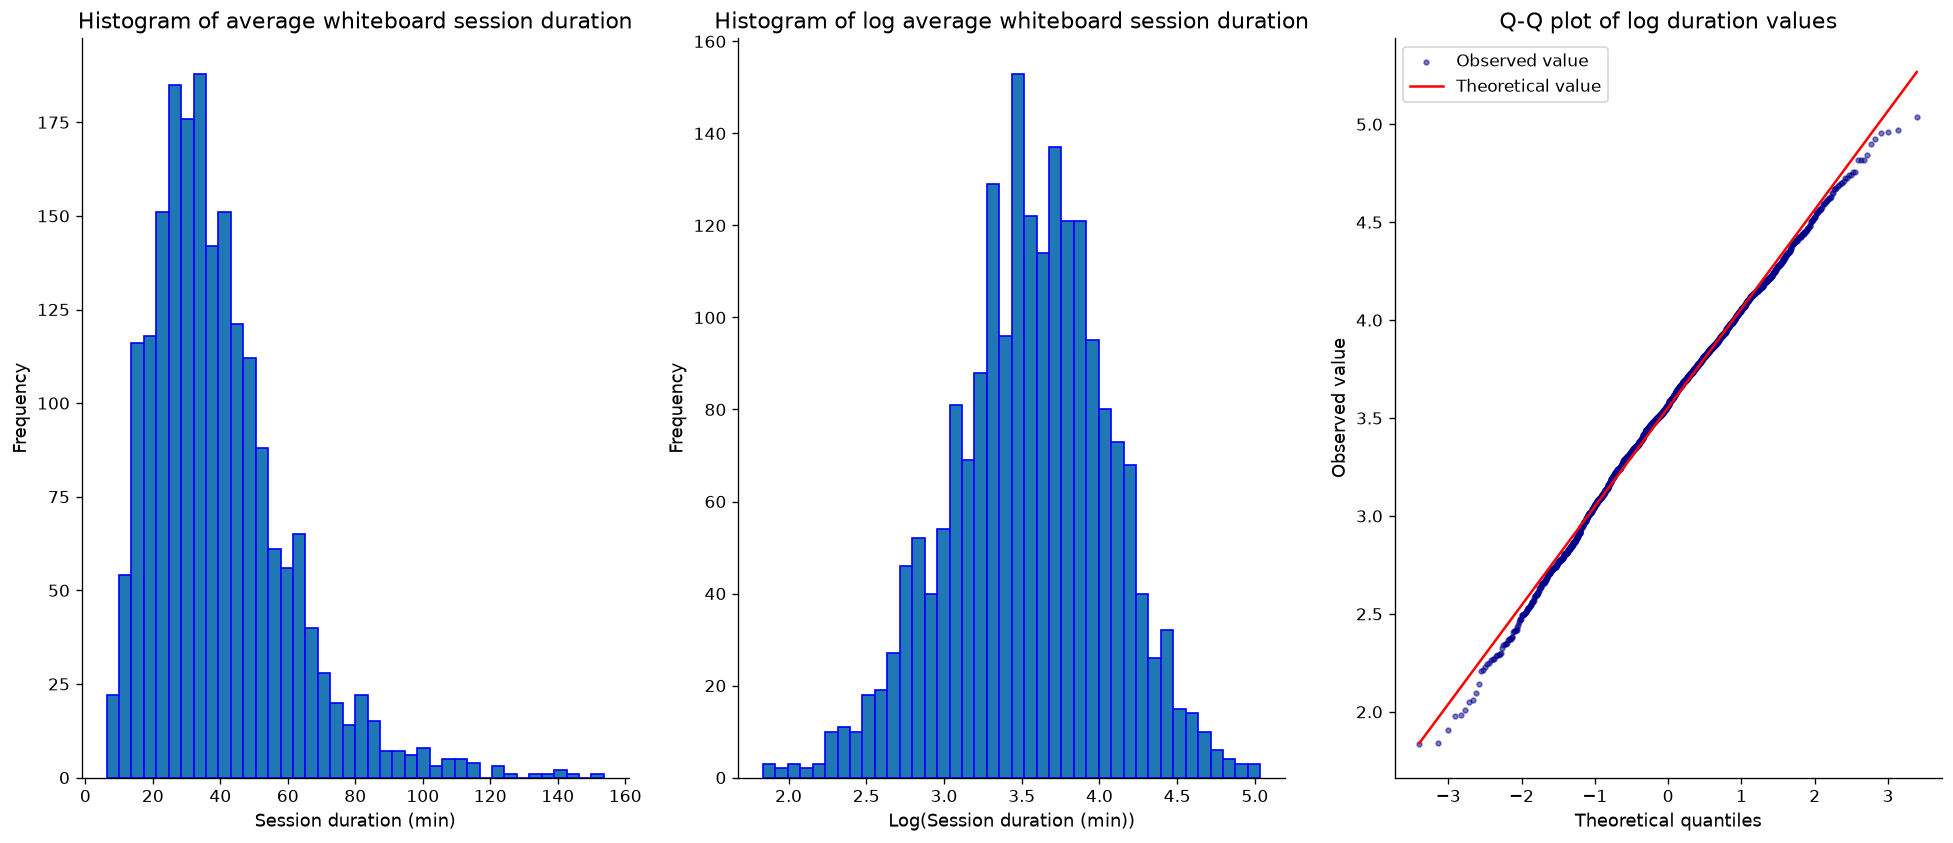

The skew for raw values is 1.38, and the skew for log values is -0.21


In [154]:
# BEGIN
#    Load target outcome variable

#    // 1. Normality & Transformation Visualizations
#    Initialize three-panel visual layout
#    
#    Draw histogram of raw outcome distribution
#    Transform outcome variable using natural logarithm
#    Draw histogram of log-transformed outcome distribution
#    Draw Q-Q plot comparing log-transformed distribution to a normal distribution
#    
#    Render visualizations
#
#    // 2. Statistical Diagnostics
#    Compute and output skewness for both raw and log-transformed distributions
# END

# Started in lab session w/Mehdi

y_raw = df_ab["avg_whiteboard_session_duration_min"]
y_log = np.log(y_raw)
fig, axes = plt.subplots(1, 3, figsize=(20,8))

# Raw histogram
axes[0].hist(y_raw, bins=40, edgecolor="blue")
axes[0].set_title("Histogram of average whiteboard session duration")
axes[0].set_xlabel("Session duration (min)")
axes[0].set_ylabel("Frequency")

# Log histogram
axes[1].hist(y_log, bins=40, edgecolor="blue")
axes[1].set_title("Histogram of log average whiteboard session duration")
axes[1].set_xlabel("Log(Session duration (min))")
axes[1].set_ylabel("Frequency")

## Q-Q plot for log values
(osm, osr), (slope, intercept, r) = stats.probplot(y_log, dist="norm")
axes[2].scatter(osm, osr, color="darkblue", s=8, alpha=0.5, label="Observed value")
axes[2].plot(osm, slope * np.array(osm) + intercept, color="red", label="Theoretical value")
axes[2].set_title("Q-Q plot of log duration values")
axes[2].set_xlabel("Theoretical quantiles")
axes[2].set_ylabel("Observed value")

plt.legend()
plt.show()

# Skew values
skew_raw = float(y_raw.skew().round(2))
skew_log = float(y_log.skew().round(2))
print(f"The skew for raw values is {skew_raw}, and the skew for log values is {skew_log}")

#### For my own curiosity, see how the Q-Q plot looks like for the raw y-values

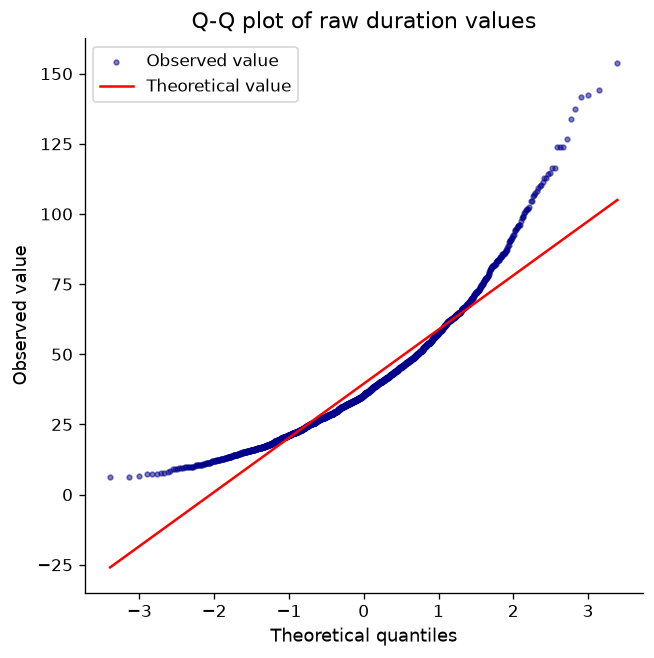

In [155]:
## Q-Q plot for raw values
fig, axes = plt.subplots(figsize=(6,6))
(osm, osr), (slope, intercept, r) = stats.probplot(y_raw, dist="norm")
axes.scatter(osm, osr, color="darkblue", s=8, alpha=0.5, label="Observed value")
axes.plot(osm, slope * np.array(osm) + intercept, color="red", label="Theoretical value")
axes.set_title("Q-Q plot of raw duration values")
axes.set_xlabel("Theoretical quantiles")
axes.set_ylabel("Observed value")

plt.legend()
plt.show()

**✏️ Your interpretation (A1.1):**

Yes the log-transformed data is more normally distributed than the raw data. Three ways to verify this:
    - Visual inspection of the histograms show that the raw data is right skewed.
    - The Q-Q plot for the log values follows the OSM graph closely, whereas we see a U shaped curve for the raw values, indiciating a skew.
    - The log values have a lower skew (-0.21) than the raw values (-1.38)

I will use the log-data in my model because it is a better starting point for modelling than heavily skewed data. Later on, we might need to work on ensuring normality of residuals.



#### A1.2 — Examine the confounders

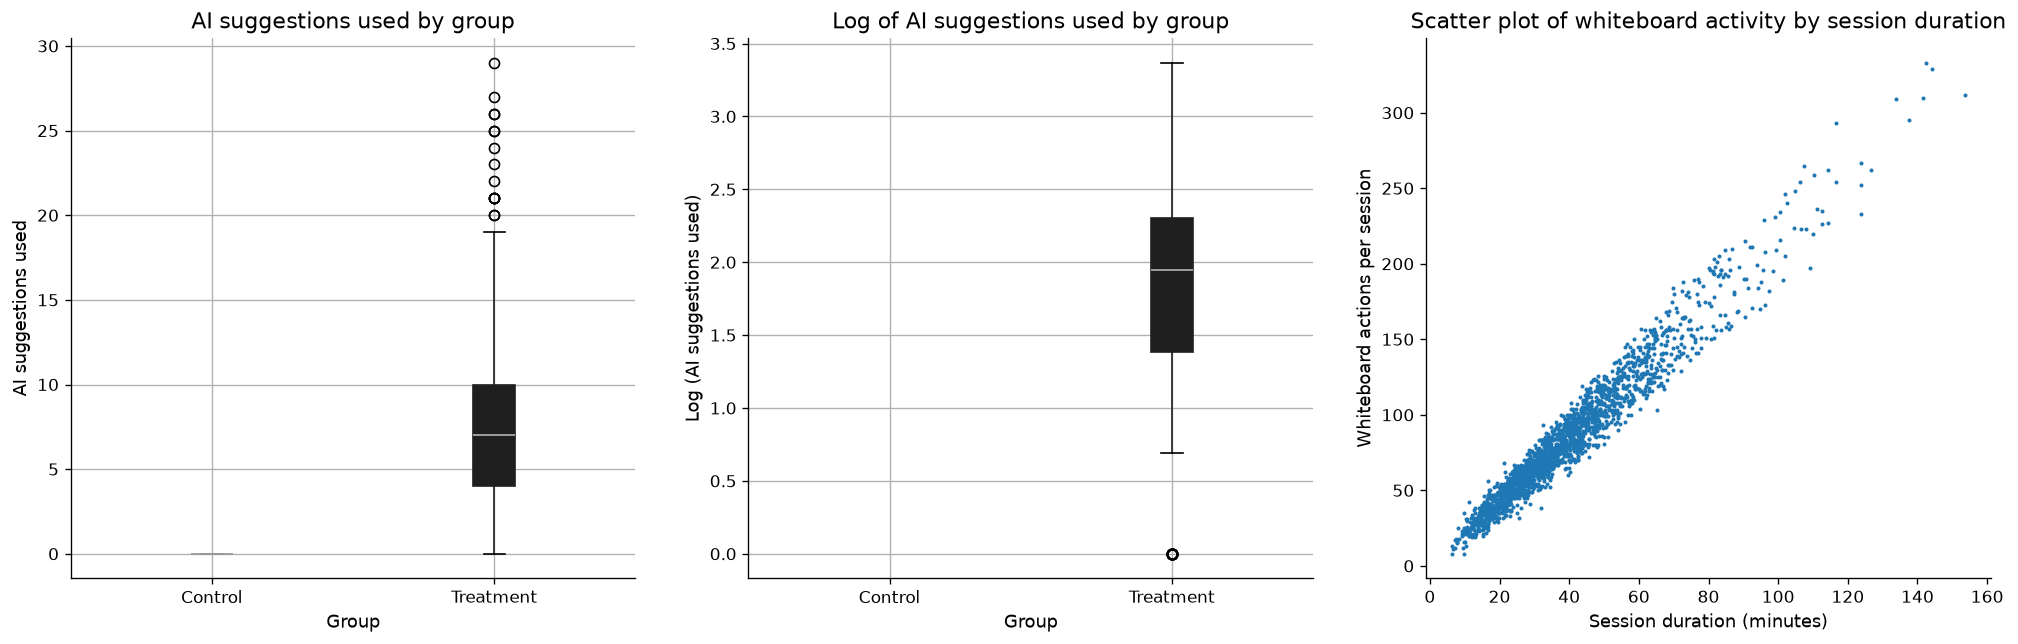

ab_group
control         0
treatment    7254
Name: ai_suggestions_used, dtype: int64

In [ ]:
# Define the analytical pipeline
# BEGIN
#    Load AB testing dataset
#
#    1. Visual Exploratory Data Analysis
#    Initialize side-by-side visualization layouts
#    
#    Draw boxplot comparison of AI suggestion usage across experimental groups
#    Draw scatter plot comparing whiteboard activity density against session durations
#    
#    Optimize layout and display visualizations
#
#    2. Statistical Analysis
#    Calculate and print the correlation between whiteboard activity and session duration
#    Calculate and print descriptive statistics for AI suggestion usage grouped by treatment group
# END

df_ab["log_ai_suggestions_used"] = np.log(df_ab["ai_suggestions_used"])
fig, axes = plt.subplots(1, 3, figsize=(20,6))

# Box plot of AI Suggestions used by group
df_ab.boxplot(column="ai_suggestions_used", by="ab_group", patch_artist=True, ax=axes[0])
axes[0].set_title("AI suggestions used by group")
axes[0].set_xlabel("Group")
axes[0].set_xticklabels(["Control", "Treatment"])
axes[0].set_ylabel("AI suggestions used")

# For my own curiosity: Box plot of AI Suggestions used (log-transformed) by group
df_ab.boxplot(column="log_ai_suggestions_used", by="ab_group", patch_artist=True, ax=axes[1])
axes[1].set_title("Log of AI suggestions used by group")
axes[1].set_xlabel("Group")
axes[1].set_xticklabels(["Control", "Treatment"])
axes[1].set_ylabel("Log (AI suggestions used)")

# Scatterplot
whiteboard_activity = df_ab["whiteboard_actions_per_session"]
axes[2].scatter(y_raw, whiteboard_activity, s=2)
axes[2].set_title("Scatter plot of whiteboard activity by session duration")
axes[2].set_xlabel("Session duration (minutes)")
axes[2].set_ylabel("Whiteboard actions per session")

fig.suptitle("") # Clear an auto-generated title
plt.show()

# Show count of AI suggestion by group
display(df_ab.groupby("ab_group")["ai_suggestions_used"].sum())

**✏️ Your interpretation (A1.2):**

There was more AI suggestions used in Treatment group. Control group had zero. This makes sense because Control group did not have access to AI features.
The scatterplot shows a positive correlation between actions per session and session duration. This makes sense because longer sessions are likely to have more actions.

I will not use either of them because:
    - AI suggestions by group is not a fair metric, because control group used zero AI suggestions, as expected, so it might unfairly weigh our regression
    - Since longer sessions naturally tend to have more actions, it really tells us nothing about whether it is influenced by AI.



#### A1.3 — Predictor distributions and relationships with outcome

In [171]:
BEGIN
    Define list of numerical predictor variables
    Compute log-transformed outcome variable

    Initialize visual grid layout (2 rows by N columns, where N is the number of predictors)

    FOR each predictor variable:
        // Top row: Univariate Analysis
        Draw histogram to show distribution of the predictor
        
        // Bottom row: Bivariate Analysis
        Draw scatter plot comparing predictor against log-transformed outcome
        Calculate correlation coefficient between predictor and log-transformed outcome
        Annotate plot with correlation coefficient
    END FOR

    Add global title and render layout
END

IndentationError: unexpected indent (3684986504.py, line 2)

In [ ]:
BEGIN
    Define list of categorical predictor variables
    Initialize visual grid layout (1 row by N columns, where N is the number of categories)

    FOR each categorical variable:
        Retrieve unique category levels
        
        Group log-transformed outcome values by category levels
        
        Draw boxplots of log-transformed outcome grouped by category level
        Rotate category axis labels for readability
        
        Label axis and set titles
    END FOR

    Render layout
END

**✏️ Your interpretation (A1.3):**

*3–5 sentences summarizing your EDA. Which predictors look most promising? Are any right-skewed and worth log-transforming before use as predictors? Which two features are you excluding and why?*


### A2 — Feature Engineering

Prepare your feature matrix for OLS. Exclude the two problematic variables identified in A1.


In [ ]:
BEGIN
    Load baseline dataset

    // 1. Encode Categorical Variables
    Convert experimental group ('ab_group') into a binary integer indicator
    Generate dummy indicators (one-hot encoding) for device types, omitting the first category
    Generate dummy indicators (one-hot encoding) for regions, omitting the first category

    // 2. Perform Optional Transformations
    Log-transform right-skewed numerical predictors using log(x + 1) to avoid zero values

    // 3. Assemble Modeling Dataset
    Merge numerical characteristics, binary groups, and dummy indicators into matrix X
    Set target vector y as the log-transformed outcome variable

    // 4. Quality Control
    Verify that there are no missing (null) values in feature matrix X
    Inspect matrix dimensions and print a preview of the processed data
END

**✏️ Your interpretation (A2):**

*List your final features. For each one, write one sentence justifying its inclusion and any transformation applied.*


### A3 — OLS Regression


In [ ]:
# YOUR CODE HERE
# Add a constant for the intercept, then fit OLS
X_const = sm.add_constant(X)
model_ols = sm.OLS(y, X_const).fit()
print(model_ols.summary())


#### A3.1 — Interpret the model

In [ ]:
BEGIN
    Input trained OLS regression model
    Input experimental dataframe

    // 1. Evaluate Model Fit
    Display model's R-squared value to assess variance explained

    // 2. Analyze Treatment Effect
    Extract coefficient and significance (p-value) for the A/B testing variable
    Convert the log-space treatment coefficient back to its scale in physical time (minutes) 
    Display treatment effect size and statistical significance

    // 3. Extract Significant Predictors
    Filter all model coefficients where p-value < 0.05
    FOR each significant variable:
        Display variable name, its directional coefficient, and its p-value
    END FOR
END

**✏️ Results paragraph (A3):**

*Write a results paragraph as if reporting in a research paper. Include:*
- *The treatment effect estimate and its significance*
- *R² and what it tells you about model fit*
- *At least two other notable predictors and their direction*
- *Whether the AI assistant's effect is practically meaningful (not just statistically significant)*


#### A3.2 — Regression diagnostics

In [ ]:
BEGIN
    Extract predictions and error terms (residuals) from regression model
    Initialize a side-by-side diagnostic visualization layout

    // Check for uniform variance (homoscedasticity)
    Draw scatter plot of prediction values vs residuals
    Overlay a horizontal zero-error baseline reference line
    
    // Check for normality of errors
    Draw a Q-Q plot of residuals against a normal theoretical distribution

    Render diagnostic plots
END

**✏️ Your interpretation (A3.2):**

*Do the residuals look randomly scattered around zero? Does the Q-Q plot suggest normally distributed errors? Note any patterns that concern you.*


### A4 — Exploratory Interaction Analysis

The average treatment effect hides heterogeneity — the AI assistant may help some users more than others.


**✏️ State your hypothesis here (before writing any code):**

*Which interaction are you testing? Which two variables? What is your theoretical reason for expecting this interaction? Which group do you predict will benefit more from the AI assistant?*


In [ ]:
# YOUR CODE HERE
# Step 1: Create the interaction term
# Example: df_ab['ab_x_device_desktop'] = df_ab['ab_group_enc'] * df_ab['device_desktop']

# Step 2: Add the interaction term to your feature matrix and refit OLS
# X_interact = pd.concat([X_const, interaction_col], axis=1)
# model_interact = sm.OLS(y, X_interact).fit()
# print(model_interact.summary())


In [ ]:
# YOUR CODE HERE
# Visualize the interaction
# Example: plot mean log(outcome) for treatment vs control, split by the moderating variable
# Use a grouped bar chart or overlapping regression lines


**✏️ Your interpretation (A4):**

*Was your hypothesis supported? What does the interaction coefficient tell you about which users benefit most from the AI assistant? What does this imply for how Phigma should roll out the feature?*


---

## Part B — Logistic Regression: Who Converts?

**Dataset:** `phigma_subscription.csv`  
**Research question:** Which behavioral and demographic factors predict whether a free-tier user subscribes within 30 days?

This dataset requires **feature engineering before modeling**. Several columns arrive as raw datetimes or aggregate counts that need transformation.


In [ ]:
df_sub = pd.read_csv('phigma_subscription.csv')

print(f"Shape: {df_sub.shape}")
print(f"\nColumn types:\n{df_sub.dtypes}")
df_sub.head(3)


In [ ]:
df_sub.describe(include='all').round(2)


### B1 — Feature Engineering

Derive the required features listed in the README before doing any modeling or EDA.


In [ ]:
# YOUR CODE HERE

# 1. Parse dates
# df_sub['signup_date'] = pd.to_datetime(df_sub['signup_date'])
# df_sub['first_session_date'] = pd.to_datetime(df_sub['first_session_date'])

# 2. days_to_first_session
# df_sub['days_to_first_session'] = (df_sub['first_session_date'] - df_sub['signup_date']).dt.days

# 3. avg_session_duration_min — handle divide-by-zero explicitly
# df_sub['avg_session_duration_min'] = ...

# 4. is_weekend_signup (1 if Saturday=5 or Sunday=6)
# df_sub['is_weekend_signup'] = df_sub['signup_date'].dt.weekday.isin([5, 6]).astype(int)

# 5. One-hot encode device_type (drop first level)
# device_dummies2 = pd.get_dummies(df_sub['device_type'], prefix='device', drop_first=True)

# 6. One-hot encode referral_source (drop first level)
# referral_dummies = pd.get_dummies(df_sub['referral_source'], prefix='ref', drop_first=True)

# 7. Encode country_tier — ordinal or one-hot (justify below)
# Option A (ordinal): df_sub['country_tier_enc'] = df_sub['country_tier'].map({'tier_1':1,'tier_2':2,'tier_3':3})
# Option B (one-hot): pd.get_dummies(...)

# 8. Assemble final feature matrix
# Drop: user_id, signup_date, first_session_date, device_type, referral_source, country_tier, subscribed
# X_sub = pd.concat([...], axis=1)
# y_sub = df_sub['subscribed']

# Confirm
# print(f"Any inf: {np.isinf(X_sub.values).any()}")
# print(f"Any NaN: {X_sub.isnull().any().any()}")
# print(f"Feature matrix shape: {X_sub.shape}")
# X_sub.head(3)


**✏️ Your interpretation (B1):**

*For each engineered feature, one sentence: why might it predict subscription? Also describe how you handled the divide-by-zero edge case for `avg_session_duration_min`.*


### B2 — EDA for Subscription


In [ ]:
# Subscription rate
rate = df_sub['subscribed'].mean()
n_pos = df_sub['subscribed'].sum()
n_total = len(df_sub)
print(f"Subscription rate: {rate:.1%}  ({n_pos} / {n_total})")
print(f"Class balance — 0: {n_total - n_pos}  |  1: {n_pos}")


In [ ]:
# YOUR CODE HERE
# Visualize subscription rates across at least 3 features
# Suggestions:
#   - Bar chart: subscription rate by referral_source
#   - Bar chart: subscription rate by country_tier
#   - Boxplot: exports_30d distribution by subscribed (0 vs 1)
#   - Bar chart: subscription rate by used_premium_feature_preview
#   - Any other feature you find interesting

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Plot 1 — YOUR CODE
# axes[0]: ...

# Plot 2 — YOUR CODE
# axes[1]: ...

# Plot 3 — YOUR CODE
# axes[2]: ...

plt.tight_layout()
plt.show()


In [ ]:
# YOUR CODE HERE
# Correlation matrix of numeric features (exclude user_id and binary outcome)
# numeric_features = X_sub.select_dtypes(include='number').columns.tolist()
# corr = X_sub[numeric_features].corr()
# Plot as heatmap


**✏️ Your interpretation (B2):**

*Which two or three features appear most strongly associated with subscription in your EDA? Are any findings counterintuitive? Note any features that appear highly correlated with each other — does this concern you?*


### B3 — Logistic Regression with statsmodels (Inferential)

We fit on the **full dataset** here to maximize statistical power for inference.  
No train/test split — the goal is to interpret coefficients, not evaluate prediction.


In [ ]:
# YOUR CODE HERE
# X_const_sub = sm.add_constant(X_sub)
# model_logit = sm.Logit(y_sub, X_const_sub).fit()
# print(model_logit.summary())


In [ ]:
# YOUR CODE HERE
# Compute odds ratios for all significant predictors (p < 0.05)
# odds_ratios = np.exp(model_logit.params)
# conf_int    = np.exp(model_logit.conf_int())
# Combine into a readable table and display
# Filter to significant only: p < 0.05


In [ ]:
# YOUR CODE HERE
# Visualize odds ratios as a horizontal bar chart (forest plot style)
# Show confidence intervals if possible
# Order bars by magnitude


**✏️ Results paragraph (B3):**

*Interpret at least three odds ratios in plain English (e.g. "Users who previewed a premium feature were X times more likely to subscribe..."). Identify at least one predictor whose sign or magnitude surprised you and offer an explanation.*


### B4 — Logistic Regression with sklearn (Predictive)


In [ ]:
# YOUR CODE HERE
# Train/test split — use these exact parameters so Part C comparisons are valid
# X_train, X_test, y_train, y_test = train_test_split(
#     X_sub, y_sub, test_size=0.2, random_state=42, stratify=y_sub
# )
# print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")
# print(f"Train positive rate: {y_train.mean():.3f}  |  Test positive rate: {y_test.mean():.3f}")


In [ ]:
# YOUR CODE HERE
# Fit sklearn LogisticRegression
# clf_lr = LogisticRegression(max_iter=1000, random_state=42)
# clf_lr.fit(X_train, y_train)
# y_pred_lr = clf_lr.predict(X_test)
# y_prob_lr = clf_lr.predict_proba(X_test)[:, 1]


In [ ]:
# YOUR CODE HERE
# Confusion matrix heatmap
# cm_lr = confusion_matrix(y_test, y_pred_lr)
# disp = ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=['Not subscribed', 'Subscribed'])
# fig, ax = plt.subplots(figsize=(5, 4))
# disp.plot(ax=ax, cmap='Blues', colorbar=False)
# plt.title('Logistic Regression — Confusion Matrix')
# plt.show()


In [ ]:
# YOUR CODE HERE
# Classification report
# print(classification_report(y_test, y_pred_lr, target_names=['Not subscribed', 'Subscribed']))
# print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_lr):.4f}")


In [ ]:
# YOUR CODE HERE
# ROC curve (save fpr_lr, tpr_lr for later comparison with Part C)
# fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
# auc_lr = roc_auc_score(y_test, y_prob_lr)

# fig, ax = plt.subplots(figsize=(6, 5))
# ax.plot(fpr_lr, tpr_lr, color=ACCENT, lw=2, label=f'Logistic Regression (AUC = {auc_lr:.3f})')
# ax.plot([0,1],[0,1], 'k--', lw=0.8)
# ax.set_xlabel('False Positive Rate')
# ax.set_ylabel('True Positive Rate')
# ax.set_title('ROC Curve — Logistic Regression')
# ax.legend()
# plt.show()


**✏️ Your interpretation (B4):**

*Which metric did you decide is most important given the class imbalance, and why? Interpret the confusion matrix: how many false negatives does the model produce? From Phigma's business perspective, what is the cost of a false negative (a user who would have subscribed but the model missed)?*


---

## Part C — Your Model: Choose, Learn, Apply, Compare

**Dataset:** `phigma_subscription.csv`  
**Same train/test split as B4.** Do not re-split.


### C1 — Choose Your Model

Available options: Decision Tree, Random Forest, Gradient Boosting, XGBoost, LightGBM, K-Nearest Neighbors, Naive Bayes, SVM, LDA, AdaBoost.


**✏️ Your chosen model:** `[Model name here]`

**Conceptual explanation (write this before any code):**

*3–5 sentences. How does this model learn from training data? What does it optimize? How is it structurally different from logistic regression? Why might it perform differently on this particular dataset given what you know about the features?*


### C2 — Fit and Evaluate


In [ ]:
# YOUR CODE HERE
# Import your chosen model, e.g.:
# from sklearn.ensemble import RandomForestClassifier
# from sklearn.tree import DecisionTreeClassifier
# from sklearn.neighbors import KNeighborsClassifier
# from sklearn.naive_bayes import GaussianNB
# from sklearn.svm import SVC
# from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
# from sklearn.ensemble import GradientBoostingClassifier, AdaBoostClassifier
# from xgboost import XGBClassifier  # pip install xgboost
# from lightgbm import LGBMClassifier  # pip install lightgbm

# Fit with default hyperparameters
# clf_c = YourModel(random_state=42)   # add random_state if supported
# clf_c.fit(X_train, y_train)
# y_pred_c = clf_c.predict(X_test)
# y_prob_c = clf_c.predict_proba(X_test)[:, 1]  # omit if model has no predict_proba (e.g. SVM)


In [ ]:
# YOUR CODE HERE
# Confusion matrix


In [ ]:
# YOUR CODE HERE
# Classification report + ROC-AUC


In [ ]:
# YOUR CODE HERE
# ROC curve (save fpr_c, tpr_c, auc_c for comparison plot)


### C3 — Model Comparison


In [ ]:
# YOUR CODE HERE
# Summary comparison table
# metrics = {
#     'Model': ['Logistic Regression', 'YOUR MODEL NAME'],
#     'ROC-AUC': [...],
#     'F1 (class 1)': [...],
#     'Precision (class 1)': [...],
#     'Recall (class 1)': [...],
# }
# pd.DataFrame(metrics).set_index('Model').round(4)


In [ ]:
# YOUR CODE HERE
# Dual ROC curve plot
# fig, ax = plt.subplots(figsize=(7, 5))
# ax.plot(fpr_lr, tpr_lr, color=ACCENT, lw=2, label=f'Logistic Regression (AUC={auc_lr:.3f})')
# ax.plot(fpr_c, tpr_c, color='steelblue', lw=2, label=f'YOUR MODEL (AUC={auc_c:.3f})')
# ax.plot([0,1],[0,1], 'k--', lw=0.8, label='Random baseline')
# ax.set_xlabel('False Positive Rate')
# ax.set_ylabel('True Positive Rate')
# ax.set_title('ROC Curve Comparison')
# ax.legend()
# plt.show()


**✏️ Comparison paragraph (C3):**

*Which model performs better, and by how much? Explain *why* the performance difference occurred — based on what you know about how each model works and the structure of this dataset (non-linearities, class imbalance, number of features). If your model performed worse than logistic regression, that is a valid finding — explain why.*


### C4 — Bonus: Hyperparameter Tuning (+5 points)

*Complete this section only if you want to attempt the bonus.*


In [ ]:
# YOUR CODE HERE (BONUS)
# from sklearn.model_selection import GridSearchCV  # or RandomizedSearchCV

# Define a parameter grid relevant to your chosen model
# param_grid = { ... }

# Run cross-validated search on the TRAINING SET ONLY
# search = GridSearchCV(YourModel(), param_grid, cv=5, scoring='roc_auc', n_jobs=-1)
# search.fit(X_train, y_train)

# print(f"Best parameters: {search.best_params_}")
# print(f"Best CV AUC:     {search.best_score_:.4f}")

# Evaluate tuned model on test set
# y_pred_tuned = search.best_estimator_.predict(X_test)
# y_prob_tuned = search.best_estimator_.predict_proba(X_test)[:, 1]
# print(f"Tuned test AUC:  {roc_auc_score(y_test, y_prob_tuned):.4f}")
# print(f"Default test AUC:{auc_c:.4f}")
# print("Did tuning meaningfully improve results? [Your one sentence here]")


---

## Submission Checklist

Before submitting, confirm:

- [ ] All `# YOUR CODE HERE` cells are completed and run without errors
- [ ] All `**✏️ Your interpretation**` cells contain your own written analysis
- [ ] The notebook runs top-to-bottom without errors (`Kernel > Restart & Run All`)
- [ ] File is named `iat461_a2_[YourName]_[SFUid].ipynb`
- [ ] PDF export is named `iat461_a2_[YourName]_[SFUid].pdf`
- [ ] All AI-assisted code blocks include `#BEGIN` / `#END` disclosure comments
